# Customer Support Analytics Project

## Project goal
This notebook analyzes a customer support dataset to understand team workload, response time, and customer satisfaction.

The main business questions are:
- How fast does the support team resolve tickets?
- Are some agents overloaded compared to others?
- Is there a relationship between response time and customer rating?
- What operational changes could improve customer satisfaction?



## 1. Import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings make tables easier to inspect in the notebook.
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)


## 2. Load raw data

The project uses three source files:
- `agents.csv` — information about support agents
- `tickets.csv` — ticket-level operational data
- `reviews.csv` — customer ratings and review comments


In [2]:

df_agents = pd.read_csv('../data/raw/agents.csv')
df_reviews = pd.read_csv('../data/raw/reviews.csv')
df_tickets = pd.read_csv('../data/raw/tickets.csv')

print('Agents:', df_agents.shape)
print('Reviews:', df_reviews.shape)
print('Tickets:', df_tickets.shape)


Agents: (19, 7)
Reviews: (990, 5)
Tickets: (1618, 10)


## 3. Initial data overview

Before cleaning, I inspect structure, missing values, duplicates, and basic statistics.


In [3]:
def inspect_dataframe(df, name):
    """Quick data quality check for one dataframe"""
    
    print(f'\n===== {name.upper()} =====')
    print('Shape:', df.shape)
    print('\nInfo:')
    display(df.info())
    print('\nMissing values:')
    display(df.isna().sum())
    print('\nDuplicates:', df.duplicated().sum())
    print('\nSample rows:')
    display(df.head())

inspect_dataframe(df_agents, 'agents')
inspect_dataframe(df_tickets, 'tickets')
inspect_dataframe(df_reviews, 'reviews')



===== AGENTS =====
Shape: (19, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   agent_id    19 non-null     object
 1   agent_name  19 non-null     object
 2   team        19 non-null     object
 3   hire_date   19 non-null     object
 4   languages   19 non-null     object
 5   shift       15 non-null     object
 6   status      19 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


None


Missing values:


agent_id      0
agent_name    0
team          0
hire_date     0
languages     0
shift         4
status        0
dtype: int64


Duplicates: 0

Sample rows:


...

None


Missing values:


review_id       0
ticket_id       0
rating         34
comment         0
review_date    15
dtype: int64


Duplicates: 25

Sample rows:


,review_id,ticket_id,rating,comment,review_date
0,R71300,T100732,5,"Fast answer, thank you",04/11/2025
1,R39559,T101258,4,Issue solved quickly,05/01/2025
2,R54308,T100744,2,I was charged twice and no clear answer,06/26/2025
3,R58794,T101291,3,Solved but took time,05/23/2025
4,R35864,T100573,5,"Fast answer, thank you",2025-03-05


In [4]:
# Checking rating values before cleaning.
df_reviews['rating'].value_counts(dropna=False)


rating
5       267
4       261
3       169
2       127
1       121
NaN      34
0         5
five      4
6         2
Name: count, dtype: int64

## 4. Data cleaning

Cleaning is done separately for each dataset. This is better than one large function because each file has different problems.


Main cleaning tasks:
- standardize column names
- trim spaces
- replace fake missing values with `NaN`
- standardize categories
- parse dates
- remove duplicates
- clean invalid ratings


In [5]:
FAKE_MISSING_VALUES = ['', ' ', 'nan', 'NaN', 'None', 'none', 'null', 'NULL']


def clean_column_names(df):
    """Standardize dataframe column names"""
    
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df


def strip_text_columns(df, columns):
    """Trim spaces in selected text columns"""

    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df


### 4.1 Clean agents data


In [ ]:
def clean_agents(df):
    """
    Clean agents data.

    Original logic kept:
    - clean column names
    - standardize text fields
    - fix known typo
    - parse hire_date
    - remove duplicate agent IDs
    """
    
    df = df.copy()

    df = clean_column_names(df)

    cols = ['agent_id', 'agent_name', 'team', 'languages', 'shift', 'status']
    df = strip_text_columns(df, cols)

    # Replace fake missing values.
    df = df.replace(FAKE_MISSING_VALUES, np.nan)

    # Standardize categories.
    df['agent_id'] = df['agent_id'].str.upper()
    df['agent_name'] = df['agent_name'].str.title()
    df['team'] = df['team'].str.title()
    df['shift'] = df['shift'].str.title()
    df['status'] = df['status'].str.lower()

    # Fix known typo.
    df['agent_name'] = df['agent_name'].replace({
        'Nadia Kovalneko': 'Nadia Kovalenko'
    })

    df['hire_date'] = pd.to_datetime(df['hire_date'], errors='coerce', format='mixed', dayfirst=False)

    # Keep the latest record for duplicated agent IDs.
    df = df.sort_values('hire_date')
    df = df.drop_duplicates(subset='agent_id', keep='last')

    df = df.reset_index(drop=True)
    return df


df_agents_clean = clean_agents(df_agents)
df_agents_clean.head()


,agent_id,agent_name,team,hire_date,languages,shift,status
0,A016,Laura Gomez,General Support,2022-03-07,"EN,ES",Evening,active
1,A009,Lucas Brown,Billing,2022-06-11,"EN,FR",Night,active
2,A007,Carlos Vega,General Support,2022-07-29,"EN,UA,RU",Night,active
3,A002,Daniel Ruiz,General Support,2022-10-13,"EN,FR",Morning,active
4,A018,Iryna Bondarenko,Account & Login,2022-10-20,"EN,DE",Morning,active


### 4.2 Clean tickets data


In [7]:
def clean_tickets(df):
    """
    Clean tickets data.

    Original logic kept:
    - remove duplicates
    - standardize text fields
    - fix language labels
    - parse ticket dates
    - keep latest duplicated ticket record
    """
    
    df = df.copy()
    df = df.drop_duplicates()

    df = clean_column_names(df)

    cols = ['ticket_id', 'channel', 'language', 'issue_type', 'priority', 'agent_id', 'customer_id', 'status']
    df = strip_text_columns(df, cols)

    df = df.replace(FAKE_MISSING_VALUES, np.nan)

    # Standardization.
    df['ticket_id'] = df['ticket_id'].str.upper()
    df['channel'] = df['channel'].str.lower()
    df['language'] = df['language'].str.upper()
    df['issue_type'] = df['issue_type'].str.title()
    df['priority'] = df['priority'].str.lower()
    df['agent_id'] = df['agent_id'].str.upper()
    df['customer_id'] = df['customer_id'].str.upper()
    df['status'] = df['status'].str.lower()

    # Fix known language variants.
    df['language'] = df['language'].replace({
        'ENGLISH': 'EN',
        'SPANISH': 'ES'
    })

    # Date parsing.
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', format='mixed')
    df['resolved_at'] = pd.to_datetime(df['resolved_at'], errors='coerce', format='mixed')

    df = df.sort_values('created_at')
    df = df.drop_duplicates(subset='ticket_id', keep='last')
    df = df.reset_index(drop=True)

    return df


df_tickets_clean = clean_tickets(df_tickets)
df_tickets_clean.head()


,ticket_id,created_at,resolved_at,channel,language,issue_type,priority,agent_id,customer_id,status
0,T101047,2025-01-01 09:07:00,2025-01-03 22:15:09,chat,ES,Technical,normal,A013,C1581,resolved
1,T100746,2025-01-01 09:10:00,2025-01-02 23:48:00,email,EN,Subscription Cancellation,normal,A006,C1688,resolved
2,T100772,2025-01-01 10:25:00,2025-01-01 12:22:00,chat,EN,Other,NaN,A004,C1687,resolved
3,T100576,2025-01-01 11:13:00,2025-01-03 03:16:00,email,EN,Subscription Cancellation,urgent,A002,C1140,resolved
4,T100925,2025-01-01 18:07:00,2025-01-03 18:01:06,email,ES,General,normal,A014,C1717,resolved


### 4.3 Clean reviews data


In [8]:
def clean_reviews(df):
    """
    Clean reviews data.

    Original logic kept and improved:
    - remove duplicates
    - parse review date
    - convert ratings written as words/numbers into numeric format
    - keep only valid ratings from 1 to 5
    """
    
    df = df.copy()
    df = df.drop_duplicates()

    df = clean_column_names(df)

    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce', format='mixed', dayfirst=False)

    df = df.replace(FAKE_MISSING_VALUES, np.nan)

    rating_map = {
        'zero': 0,
        'one': 1,
        'two': 2,
        'three': 3,
        'four': 4,
        'five': 5,
        'six': 6
    }

    rating_clean = df['rating'].astype(str).str.lower().str.strip()

    # First map word ratings, then convert numeric-looking values.
    df['rating'] = rating_clean.map(rating_map)
    df['rating'] = df['rating'].fillna(pd.to_numeric(rating_clean, errors='coerce'))

    # Improvement: Int64 allows missing values, unlike normal int.
    df['rating'] = df['rating'].astype('Int64')

    # Keep only valid 1-5 ratings.
    df = df[df['rating'].between(1, 5)]

    df = df.reset_index(drop=True)
    return df


df_reviews_clean = clean_reviews(df_reviews)
df_reviews_clean.head()


,review_id,ticket_id,rating,comment,review_date
0,R71300,T100732,5,"Fast answer, thank you",2025-04-11
1,R39559,T101258,4,Issue solved quickly,2025-05-01
2,R54308,T100744,2,I was charged twice and no clear answer,2025-06-26
3,R58794,T101291,3,Solved but took time,2025-05-23
4,R35864,T100573,5,"Fast answer, thank you",2025-03-05


## 5. Validate cleaned data

After cleaning, I check the output again to make sure the cleaning functions worked as expected.


In [9]:
inspect_dataframe(df_agents_clean, 'agents_clean')
inspect_dataframe(df_tickets_clean, 'tickets_clean')
inspect_dataframe(df_reviews_clean, 'reviews_clean')



===== AGENTS_CLEAN =====
Shape: (18, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   agent_id    18 non-null     object        
 1   agent_name  18 non-null     object        
 2   team        18 non-null     object        
 3   hire_date   18 non-null     datetime64[ns]
 4   languages   18 non-null     object        
 5   shift       14 non-null     object        
 6   status      18 non-null     object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.1+ KB


None


Missing values:


agent_id      0
agent_name    0
team          0
hire_date     0
languages     0
shift         4
status        0
dtype: int64


Duplicates: 0

Sample rows:


...

None


Missing values:


review_id      0
ticket_id      0
rating         0
comment        0
review_date    4
dtype: int64


Duplicates: 0

Sample rows:


,review_id,ticket_id,rating,comment,review_date
0,R71300,T100732,5,"Fast answer, thank you",2025-04-11
1,R39559,T101258,4,Issue solved quickly,2025-05-01
2,R54308,T100744,2,I was charged twice and no clear answer,2025-06-26
3,R58794,T101291,3,Solved but took time,2025-05-23
4,R35864,T100573,5,"Fast answer, thank you",2025-03-05


## 6. Merge datasets

The datasets are merged to create two analysis tables:
- `df_main`: tickets + agent information
- `df_reviews_full`: reviews + ticket information



In [10]:
df_main = df_tickets_clean.merge(
    df_agents_clean,
    on='agent_id',
    how='left',
    suffixes=('_ticket', '_agent')
)

df_reviews_full = df_reviews_clean.merge(
    df_tickets_clean,
    on='ticket_id',
    how='left',
    suffixes=('_review', '_ticket')
)

print('Main table:', df_main.shape)
print('Reviews full table:', df_reviews_full.shape)

df_main.head()


Main table: (1600, 16)
Reviews full table: (924, 14)


,ticket_id,created_at,resolved_at,channel,language,issue_type,priority,agent_id,customer_id,status_ticket,agent_name,team,hire_date,languages,shift,status_agent
0,T101047,2025-01-01 09:07:00,2025-01-03 22:15:09,chat,ES,Technical,normal,A013,C1581,resolved,Hugo Fernandez,Billing,2025-10-31,"EN,RU",Morning,on leave
1,T100746,2025-01-01 09:10:00,2025-01-02 23:48:00,email,EN,Subscription Cancellation,normal,A006,C1688,resolved,Nadia Kovalenko,Technical Support,2024-02-15,"EN,UA,RU",Evening,active
2,T100772,2025-01-01 10:25:00,2025-01-01 12:22:00,chat,EN,Other,NaN,A004,C1687,resolved,Ivan Petrov,Billing,2025-05-17,"EN,DE",NaN,on leave
3,T100576,2025-01-01 11:13:00,2025-01-03 03:16:00,email,EN,Subscription Cancellation,urgent,A002,C1140,resolved,Daniel Ruiz,General Support,2022-10-13,"EN,FR",Morning,active
4,T100925,2025-01-01 18:07:00,2025-01-03 18:01:06,email,ES,General,normal,A014,C1717,resolved,Clara Sanchez,General Support,2023-05-17,"EN,UA,RU",NaN,active


In [11]:
# Check if any tickets do not have matching agent information.
missing_agents = df_main['agent_name'].isna().sum()
print('Tickets without matching agent:', missing_agents)

# Check if any reviews do not have matching ticket information.
missing_tickets_for_reviews = df_reviews_full['created_at'].isna().sum()
print('Reviews without matching ticket:', missing_tickets_for_reviews)


Tickets without matching agent: 56
Reviews without matching ticket: 14


## 7. Feature engineering

I create `response_time_hours` as the difference between ticket creation and resolution time.



In [12]:

df_main['response_time_hours'] = (df_main['resolved_at'] - df_main['created_at']).dt.total_seconds() / 3600
df_reviews_full['response_time_hours'] = (df_reviews_full['resolved_at'] - df_reviews_full['created_at']).dt.total_seconds() / 3600

# Remove negative response times because resolved_at cannot logically happen before created_at.
invalid_main = (df_main['response_time_hours'] < 0).sum()
invalid_reviews = (df_reviews_full['response_time_hours'] < 0).sum()

print('Invalid negative response times in main table:', invalid_main)
print('Invalid negative response times in reviews table:', invalid_reviews)

df_main = df_main[df_main['response_time_hours'] >= 0].copy()
df_reviews_full = df_reviews_full[df_reviews_full['response_time_hours'] >= 0].copy()

# Optional outlier treatment for review analysis.
q95 = df_reviews_full['response_time_hours'].quantile(0.95)
df_reviews_full_no_outliers = df_reviews_full[df_reviews_full['response_time_hours'] <= q95].copy()

print('95th percentile response time:', round(q95, 2))
print('Reviews before outlier filter:', len(df_reviews_full))
print('Reviews after outlier filter:', len(df_reviews_full_no_outliers))


Invalid negative response times in main table: 128
Invalid negative response times in reviews table: 74
95th percentile response time: 2187.43
Reviews before outlier filter: 733
Reviews after outlier filter: 696


## 8. KPI calculation

Main KPIs:
- total tickets
- average response/resolution time
- tickets per agent
- overloaded agents
- average rating per agent
- relationship between rating and response time
- percentage of low ratings


In [13]:
# Tickets per agent.
tickets_per_agent = df_main.groupby('agent_id')['ticket_id'].count().sort_values(ascending=False)

# Average response/resolution time per agent.
avg_response_per_agent = df_main.groupby('agent_id')['response_time_hours'].mean().sort_values(ascending=False)

# Overloaded agents: agents above 75th percentile by ticket count.
threshold = tickets_per_agent.quantile(0.75)
overloaded_agents = tickets_per_agent[tickets_per_agent > threshold]

# Active vs inactive workload.
active_inactive_workload = df_main.groupby('status_agent')['ticket_id'].count().sort_values(ascending=False)

# Average rating per agent.
avg_rating_per_agent = df_reviews_full_no_outliers.groupby('agent_id')['rating'].mean().sort_values(ascending=True)

# Rating vs response time.
rating_response = df_reviews_full_no_outliers.groupby('rating')['response_time_hours'].mean()

# Percentage of low ratings.
low_rating_pct = (df_reviews_full_no_outliers['rating'].isin([1, 2]).mean()) * 100

kpi_summary = pd.DataFrame({
    'metric': [
        'Total tickets',
        'Total reviews used',
        'Average response/resolution time (hours)',
        'Median response/resolution time (hours)',
        'Low rating percentage (1-2 stars)'
    ],
    'value': [
        len(df_main),
        len(df_reviews_full_no_outliers),
        round(df_main['response_time_hours'].mean(), 2),
        round(df_main['response_time_hours'].median(), 2),
        round(low_rating_pct, 2)
    ]
})

kpi_summary


,metric,value
0,Total tickets,1274.00
1,Total reviews used,696.00
2,Average response/resolution time (hours),272.70
3,Median response/resolution time (hours),24.21
4,Low rating percentage (1-2 stars),26.29


## 9. Exploratory Data Analysis (EDA)


### 9.1 Ticket volume by agent


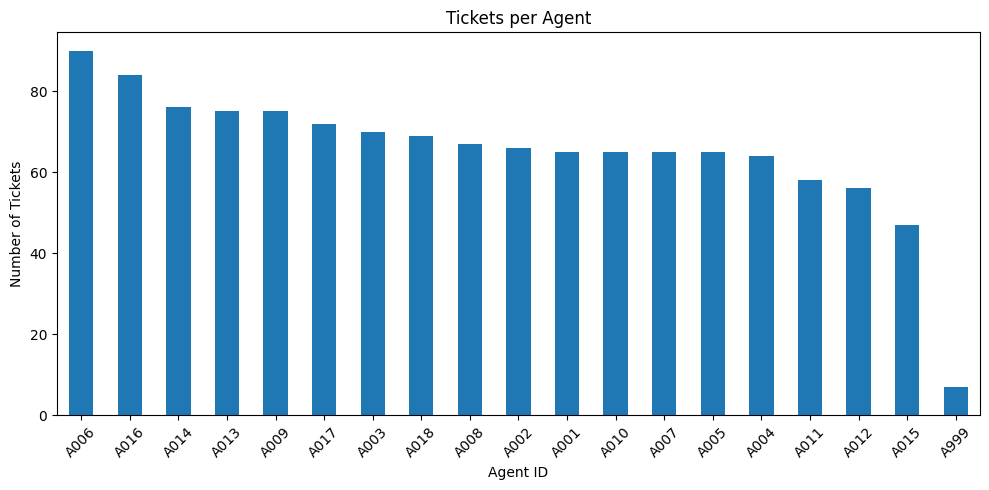

Overloaded agents based on 75th percentile threshold:


agent_id
A006    90
A016    84
A014    76
A013    75
A009    75
Name: ticket_id, dtype: int64

In [14]:
tickets_per_agent.plot(kind='bar', figsize=(10, 5))
plt.title('Tickets per Agent')
plt.xlabel('Agent ID')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Overloaded agents based on 75th percentile threshold:')
display(overloaded_agents)


**Interpretation:** Agents above the 75th percentile handle significantly more tickets than the rest of the team. This may indicate workload imbalance and potential risk of slower responses or lower quality.


### 9.2 Average response/resolution time by agent


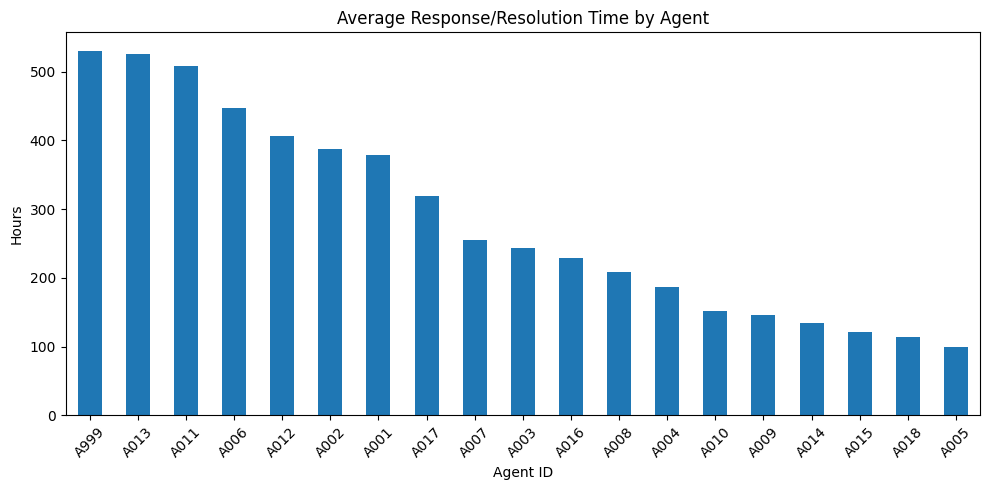

agent_id
A999    530.689246
A013    525.889319
A011    508.551260
A006    447.266630
A012    406.720327
A002    387.667382
A001    378.931855
A017    318.735625
A007    254.836526
A003    243.304107
Name: response_time_hours, dtype: float64

In [15]:
avg_response_per_agent.plot(kind='bar', figsize=(10, 5))
plt.title('Average Response/Resolution Time by Agent')
plt.xlabel('Agent ID')
plt.ylabel('Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

avg_response_per_agent.head(10)


**Interpretation:** Some agents have much higher average resolution time. This could be caused by ticket complexity, workload, shift type, or process inefficiencies. A fair performance review should compare agents by issue type and priority, not only raw averages.


### 9.3 Rating vs response/resolution time


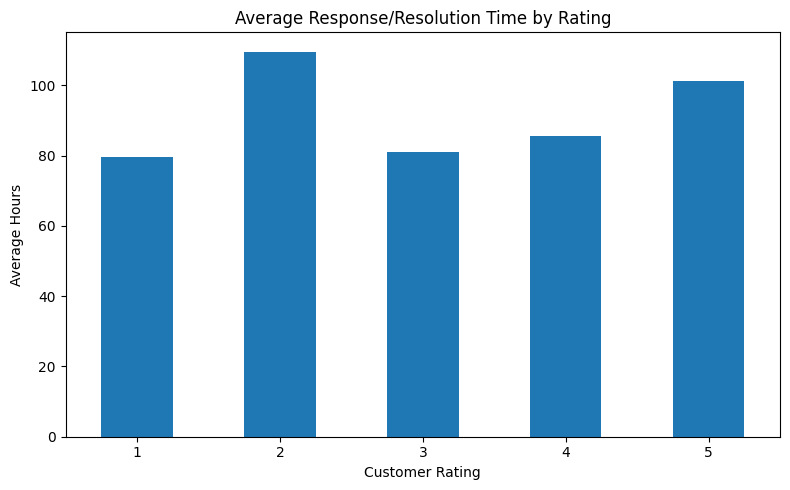

rating
1     79.603460
2    109.604191
3     81.003066
4     85.548332
5    101.224845
Name: response_time_hours, dtype: float64

In [16]:
rating_response.plot(kind='bar', figsize=(8, 5))
plt.title('Average Response/Resolution Time by Rating')
plt.xlabel('Customer Rating')
plt.ylabel('Average Hours')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rating_response


**Interpretation:** This chart helps check whether lower ratings are linked to slower ticket handling. If low ratings have much higher response/resolution time, the support team should prioritize faster handling for urgent or sensitive cases.


### 9.4 Response/resolution time distribution by rating


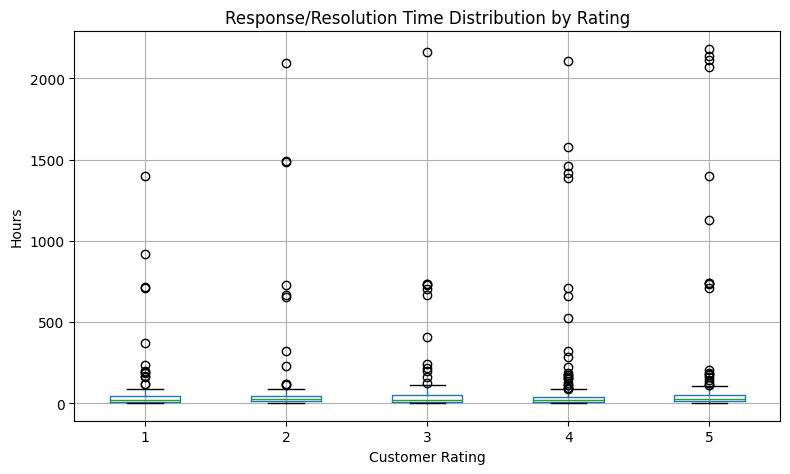

In [17]:
df_reviews_full_no_outliers.boxplot(column='response_time_hours', by='rating', figsize=(8, 5))
plt.title('Response/Resolution Time Distribution by Rating')
plt.suptitle('')
plt.xlabel('Customer Rating')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()


**Interpretation:** The boxplot is useful because averages can be distorted by extreme cases. This view shows whether low ratings generally have longer response times or only a few outliers.


### 9.5 Rating distribution


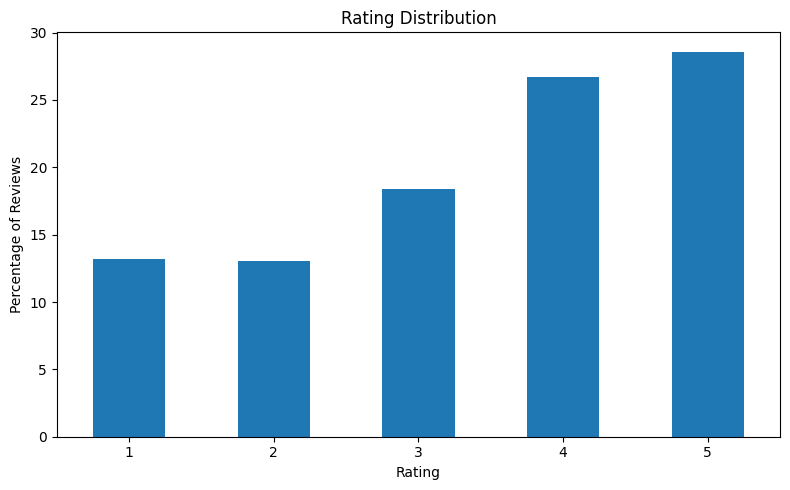

rating
1    13.22
2    13.07
3    18.39
4    26.72
5    28.59
Name: proportion, dtype: Float64

In [18]:
rating_distribution = df_reviews_full_no_outliers['rating'].value_counts(normalize=True).sort_index() * 100

rating_distribution.plot(kind='bar', figsize=(8, 5))
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

rating_distribution.round(2)


**Interpretation:** Rating distribution shows the general satisfaction level. A high share of 1–2 star ratings would indicate a stronger need for operational improvements.


## 10. Business insights

Based on the analysis, the main findings are:

1. **Workload is not evenly distributed.** Some agents handle more tickets than others.
2. **Response/resolution time varies by agent.** This may reflect workload, shift, ticket complexity, or process issues.
3. **Low ratings should be monitored separately.** They may be connected to slow resolution, billing issues, or unclear communication.
4. **Negative or invalid response times were found.** This indicates data quality issues in timestamps and should be fixed at the source.




## 11. Recommendations

Recommended actions for a support manager:

1. **Balance ticket workload** between agents to avoid overload.
2. **Create SLA targets** for response/resolution time, especially for high-priority tickets.
3. **Investigate low ratings** and tag common reasons such as billing, technical issues, or slow support.
4. **Improve data tracking**, especially timestamp accuracy and missing values.
5. **Build a simple risk flag** for tickets likely to receive low ratings.


## 12. Save cleaned outputs

The cleaned and merged tables are saved for later use in Tableau, SQL, or dashboard creation.


In [19]:
df_agents_clean.to_csv('../data/processed/agents_clean.csv', index=False)
df_reviews_clean.to_csv('../data/processed/reviews_clean.csv', index=False)
df_tickets_clean.to_csv('../data/processed/tickets_clean.csv', index=False)
df_main.to_csv('../data/processed/main.csv', index=False)
df_reviews_full_no_outliers.to_csv('../data/processed/df_reviews_full.csv', index=False)

print('Files saved successfully.')


Files saved successfully.


## 13. Possible next step: simple ML idea

This project can be extended with beginner-friendly machine learning.

Possible target:
- predict whether a review will be low rating (`1` if rating <= 2, else `0`)

Possible features:
- response/resolution time
- priority
- channel
- issue type
- language
- agent/team

